Let's  consider the case of nucleation and association.

Given are 
* the initial amount of monomers $m_0$, 
* the nucleation number $n_c$ and 
* the rate of nucleation $k_n$.
* the rate of assocaitation $k_a$

We assume that all polymers of size $< n_c$ immediately fal appart into monomers.

We will denote the amount of monomers at a given moment of time by $m(t) = m_0 - M(t)$, where $M(t)$ is the mass or aggregates/polymers.

$$\frac{df(t,j)}{dt} = k_n(m(t))^{n_c} + k_a\cdot m(t)\cdot [f(t,j-1) - f(t,j)]  $$

In [21]:
import random as random
import numpy as np
import matplotlib.pyplot as plt

Mt = lambda f,j : np.sum(j*f)
Pt = lambda f : np.sum(f)

def calc_assoc_rates(ka,mt,f, assoc_rates):
    for j in range(1,len(f)):
        assoc_rates[j] = ka*mt*f[j-1]
    return assoc_rates

#Parameters
kn, ka, nc = 1e-6, 1e-2, 3  # rates of nucleation/association & nucleation size
tmax, jmax = 200, 20 # 200, 10

# 0. Set initial conditions
m0 = 2000
t = 0

f, j, assoc_rates = np.zeros(jmax), np.arange(0,jmax), np.zeros(jmax)   # make list for recording number of polymers of a given length
ft, tt, Mtt, Ptt = [np.copy(f)], [t], [Mt(f,j)], [Pt(f)]      # make lists for saving the values
#run Gillspie 
total_rate = 1
while t <= tmax and total_rate > 0:
    #1. update rates
    mt = m0 - Mt(f,j)
    nucl_rate = kn*mt**nc #nucl rate, 
    assoc_rates = calc_assoc_rates(ka, mt, f, assoc_rates)#association rates, one per each polymer length 
    #total rate
    total_rate = nucl_rate + np.sum(assoc_rates)
    if total_rate <= 0:
        print('total_rate=', total_rate)
        break
    
    #2. time to next reaction
    rn1 = random.random()
    tau = -1/total_rate*np.log(rn1) #the time to next reaction , from exponential distribution, rn = 1-exp(-total_rate*tau), or because 1-rn is also a rn, rn = exp(-total_rate*tau)
    
    #3. find wich reaction (production or degradation) will take place
    rn2  = random.random()
    done = False #This variable will be used to track if a reaction is realized or not
    if(rn2 < nucl_rate/total_rate):
        f[nc] = f[nc] + 1 # creation reaction
        done = True
    else :
        current_rate = nucl_rate
        for jj in range(nc+1, jmax):
            current_rate = current_rate + assoc_rates[jj]
            if(not done) and (rn2 < current_rate /total_rate):
                f[jj] = f[jj] + 1
                f[jj-1] = f[jj-1] - 1
                done = True
                break

    # 4. advance in time with tau
    t = t + tau

    # save values for plotting
    ft.append(np.copy(f))
    Mtt.append(Mt(f,j))
    Ptt.append(Pt(f))
    tt.append(t)

ft, tt, Mtt, Ptt = np.array(ft), np.array(tt), np.array(Mtt), np.array(Ptt)

total_rate= 0.0


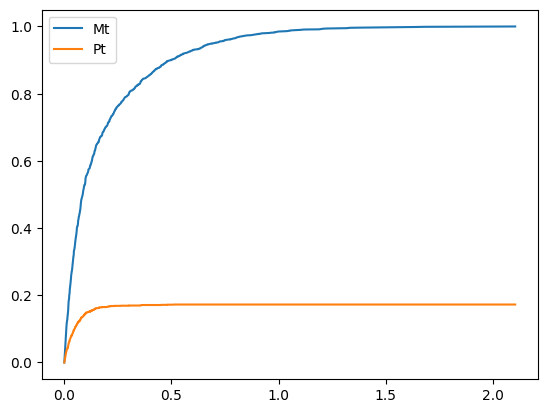

In [22]:
# print(np.shape(ft)); print(ft[-1,:]); print(tt); print(f'total_rate={total_rate}') 
plt.plot(tt,Mtt/m0,label='Mt'); plt.plot(tt,Ptt/m0,label='Pt') # how does M(t),P(t) look
plt.legend()

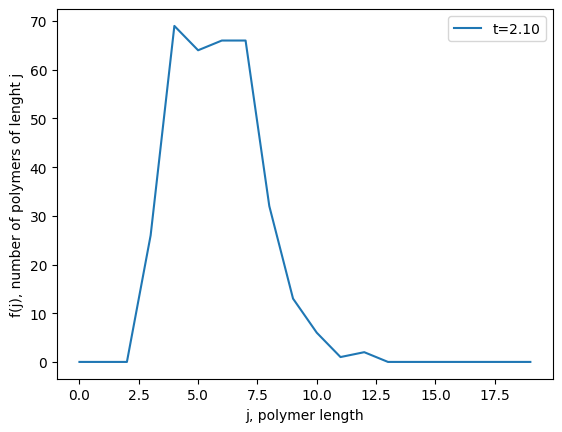

In [23]:
# how does f(t,j) looks at a given time point? 
t_idx = -1# index 
plt.plot(ft[t_idx,:])
plt.xlabel('j, polymer length')
plt.ylabel('f(j), number of polymers of lenght j')
plt.legend([f't={tt[t_idx]:0.2f}'])

Text(0, 0.5, 'f(j)')

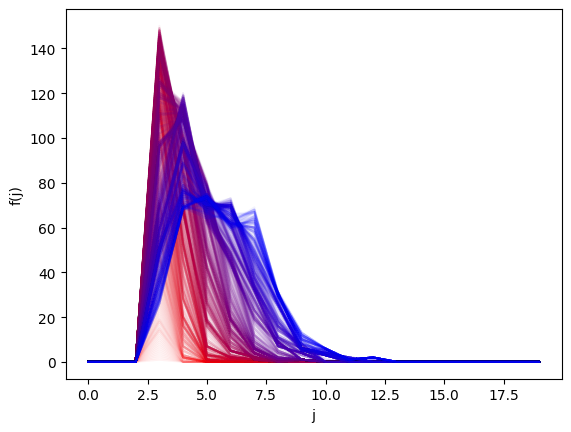

In [24]:
# combining all  times
T = len(tt)
for i in range(1,T):
    plt.plot(ft[i,:], color=((T-i)/T,0,i/T), alpha=0.05)
plt.xlabel('j'); plt.ylabel('f(j)')
#plt.legend(tt)